In [14]:
%matplotlib inline
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import itertools
import math
from matplotlib.colors import LogNorm
import time
#from numpy.random import *
import numexpr as ne
from IPython.display import clear_output
import os
import warnings
warnings.filterwarnings('ignore')
#from google.colab import drive
#drive.mount('/content/drive')

In [15]:
def axb(x,a,b):
    y = a*x + b
    return y

In [16]:
def axbfit(x,_p_):
    _a_ = _p_[:,0].reshape(num_temp,1)
    _b_ = _p_[:,1].reshape(num_temp,1)
    y = axb(x,_a_,_b_)
    return y

In [4]:
# メトロポリス法によるパラメータ更新
def update_param(i,E,n,num_para,sigma_R,x,y,_p_,ratio_p,rslt_p,_rslt_p0_,_rslt_p1_,stepsize_p0,stepsize_p1,
                 _ratio_p_,num_temp,_p_min_,_p_max_,burn_in_length):
    #num_para = np.size(_p_max_)
    # temp=0はprior（事前分布）に基づいてサンプリング
    _p_[0,0] = (_p_max_[0]-_p_min_[0])*np.random.rand()+_p_min_[0]
    _p_[0,1] = (_p_max_[1]-_p_min_[1])*np.random.rand()+_p_min_[1]

    for _ii_ in range(num_para):
        _select_ = np.random.randint(0,num_para,num_temp) #パラメータ間の相関がサンプリングに影響しないようにランダムにパラメータ選択して更新。
        #_select_ = int(_ii_)*np.ones(num_temp,dtype="int8") # 順番にパラメータ更新する場合
        _next_p_ = 1*_p_
        for _j_ in range(1,num_temp):# temp=0は別のサンプリングを行う
            _ratio_p_[num_para*_j_+_select_[_j_]] = np.append(_ratio_p_[num_para*_j_+_select_[_j_]],0)
            if(_select_[_j_]==0):
                _next_p_[_j_,0] += stepsize_p0[_j_]*(2*np.random.rand()-1)
            if(_select_[_j_]==1):
                _next_p_[_j_,1] += stepsize_p1[_j_]*(2*np.random.rand()-1)

        _y_ = axbfit(x,_next_p_)
        next_E = 1/2/n/sigma_R**2*np.linalg.norm(y-(
                 _y_
                 ),axis=1)**2

        prob = np.exp(-n*temp*(next_E-E)) - np.random.rand(num_temp)
        J = np.where(prob>0)
        for _jj_ in J[0]:
            if(_p_min_[_select_[_jj_]]<= _next_p_[_jj_,_select_[_jj_]]<=_p_max_[_select_[_jj_]]):
                _p_[_jj_,_select_[_jj_]] = _next_p_[_jj_,_select_[_jj_]]
                E[_jj_] = next_E[_jj_]
                if(_jj_>0):
                    (_ratio_p_[num_para*_jj_+_select_[_jj_]])[-1] +=1#採択率についての履歴を残す
                if(i>=burn_in_length):
                    ratio_p[_jj_,_select_[_jj_]] += 1#採択率そのもの
        rslt_p[_select_[num_temp-1]] = np.append(rslt_p[_select_[num_temp-1]],_p_[num_temp-1,_select_[num_temp-1]])#最低温の履歴
        for _kk_ in range(1,num_temp):#全レプリカのサンプリング履歴を残す
            if(_select_[_kk_]==0):
                _rslt_p0_[_kk_] = np.append(_rslt_p0_[_kk_],_p_[_kk_,0])
            if(_select_[_kk_]==1):
                _rslt_p1_[_kk_] = np.append(_rslt_p1_[_kk_],_p_[_kk_,1])

    #temp=0は必ず更新
    E[0] = next_E[0]
    ratio_p[0,:] = 0
    _rslt_p0_[0] = np.append(_rslt_p0_[0],_p_[0,0])
    _rslt_p1_[0] = np.append(_rslt_p1_[0],_p_[0,1])

    return E

In [5]:
# 擬似フォークト関数
# ローレンツ関数とガウス関数の幅を別々に設定
def psV(x,mu,w_l,w_g,A,x0):
    y = A*(mu*2/np.pi*w_l/(4*(x-x0)**2+w_l**2)+(1-mu)*np.sqrt(4*np.log(2))/np.sqrt(np.pi)/w_g*np.exp(-4*np.log(2)/w_g**2*(x-x0)**2))
    return y
# ローレンツ関数とガウス関数の幅を共通
#def psV(x,mu,w,A,x0):
#    y = A*(mu*2/np.pi*w/(4*(x-x0)**2+w**2)+(1-mu)*np.sqrt(4*np.log(2))/np.sqrt(np.pi)/w*np.exp(-4*np.log(2)/w**2*(x-x0)**2))
#    return y

In [6]:
def psVfit(x,_p_):
    A1   = _p_[:,0].reshape(num_temp,1)
    mu1  = _p_[:,1].reshape(num_temp,1)
    w_l1 = _p_[:,2].reshape(num_temp,1)
    w_g1 = _p_[:,3].reshape(num_temp,1)
    x1   = _p_[:,4].reshape(num_temp,1)
    A2   = _p_[:,5].reshape(num_temp,1)
    mu2  = _p_[:,6].reshape(num_temp,1)
    w_l2 = _p_[:,7].reshape(num_temp,1)
    w_g2 = _p_[:,8].reshape(num_temp,1)
    x2   = _p_[:,9].reshape(num_temp,1)
    y = psV(x,mu1,w_l1,w_g1,A1,x1) + psV(x,mu2,w_l2,w_g2,A2,x2)
    return y

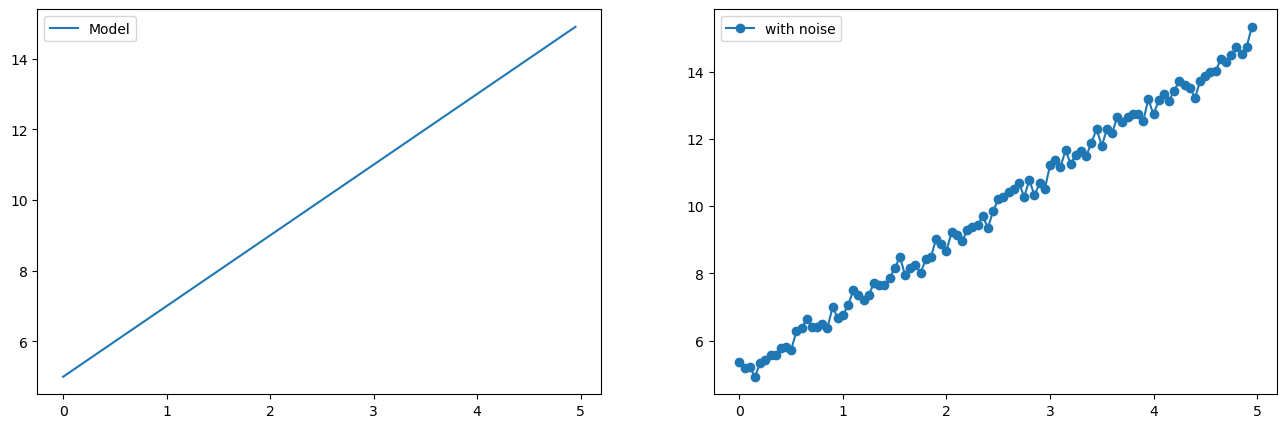

In [7]:
# シミュレーション用のデータを作成
sigma_R_sim = 0.2 # ノイズの標準偏差
_n_ = 100 # データ点数
np.random.seed(seed=3) # 乱数のシードを設定

x = np.arange(_n_)/20 # x軸を作成
a = 2
b = 5
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.plot(x,axb(x,a,b),label="Model")
plt.legend()
plt.subplot(1,2,2)
y = axb(x,a,b) + np.random.normal(loc=0, scale=sigma_R_sim,size=_n_)
plt.plot(x,y,marker="o",label="with noise")
plt.legend()
plt.show()

In [8]:
x

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
       1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
       1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15,
       2.2 , 2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 ,
       2.75, 2.8 , 2.85, 2.9 , 2.95, 3.  , 3.05, 3.1 , 3.15, 3.2 , 3.25,
       3.3 , 3.35, 3.4 , 3.45, 3.5 , 3.55, 3.6 , 3.65, 3.7 , 3.75, 3.8 ,
       3.85, 3.9 , 3.95, 4.  , 4.05, 4.1 , 4.15, 4.2 , 4.25, 4.3 , 4.35,
       4.4 , 4.45, 4.5 , 4.55, 4.6 , 4.65, 4.7 , 4.75, 4.8 , 4.85, 4.9 ,
       4.95])

In [9]:
x

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
       1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
       1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15,
       2.2 , 2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 ,
       2.75, 2.8 , 2.85, 2.9 , 2.95, 3.  , 3.05, 3.1 , 3.15, 3.2 , 3.25,
       3.3 , 3.35, 3.4 , 3.45, 3.5 , 3.55, 3.6 , 3.65, 3.7 , 3.75, 3.8 ,
       3.85, 3.9 , 3.95, 4.  , 4.05, 4.1 , 4.15, 4.2 , 4.25, 4.3 , 4.35,
       4.4 , 4.45, 4.5 , 4.55, 4.6 , 4.65, 4.7 , 4.75, 4.8 , 4.85, 4.9 ,
       4.95])

In [10]:
y

array([ 5.35772569,  5.18730197,  5.21929949,  4.92730146,  5.34452236,
        5.4290482 ,  5.5834517 ,  5.57459986,  5.79123637,  5.80455639,
        5.73722705,  6.27692448,  6.37626361,  6.64191461,  6.41000673,
        6.41906452,  6.49092801,  6.39070454,  6.99647349,  6.67978647,
        6.76299069,  7.05887002,  7.49722967,  7.34734325,  7.19524297,
        7.35740136,  7.72504899,  7.66789733,  7.64623273,  7.85399386,
        8.14901125,  8.49522216,  7.95117533,  8.17471662,  8.23924678,
        8.01618337,  8.4152416 ,  8.49522485,  9.02479559,  8.87361715,
        8.67534291,  9.22933509,  9.12874585,  8.95137179,  9.28067007,
        9.38228112,  9.42522354,  9.70594276,  9.35034845,  9.84644763,
       10.20263669, 10.27055957, 10.4216375 , 10.52387813, 10.69750863,
       10.27633986, 10.76916668, 10.32782209, 10.67942298, 10.51710559,
       11.2096295 , 11.36674756, 11.16051706, 11.65492901, 11.2650545 ,
       11.53012337, 11.63058914, 11.48716095, 11.88758932, 12.28

In [11]:
y

array([ 5.35772569,  5.18730197,  5.21929949,  4.92730146,  5.34452236,
        5.4290482 ,  5.5834517 ,  5.57459986,  5.79123637,  5.80455639,
        5.73722705,  6.27692448,  6.37626361,  6.64191461,  6.41000673,
        6.41906452,  6.49092801,  6.39070454,  6.99647349,  6.67978647,
        6.76299069,  7.05887002,  7.49722967,  7.34734325,  7.19524297,
        7.35740136,  7.72504899,  7.66789733,  7.64623273,  7.85399386,
        8.14901125,  8.49522216,  7.95117533,  8.17471662,  8.23924678,
        8.01618337,  8.4152416 ,  8.49522485,  9.02479559,  8.87361715,
        8.67534291,  9.22933509,  9.12874585,  8.95137179,  9.28067007,
        9.38228112,  9.42522354,  9.70594276,  9.35034845,  9.84644763,
       10.20263669, 10.27055957, 10.4216375 , 10.52387813, 10.69750863,
       10.27633986, 10.76916668, 10.32782209, 10.67942298, 10.51710559,
       11.2096295 , 11.36674756, 11.16051706, 11.65492901, 11.2650545 ,
       11.53012337, 11.63058914, 11.48716095, 11.88758932, 12.28

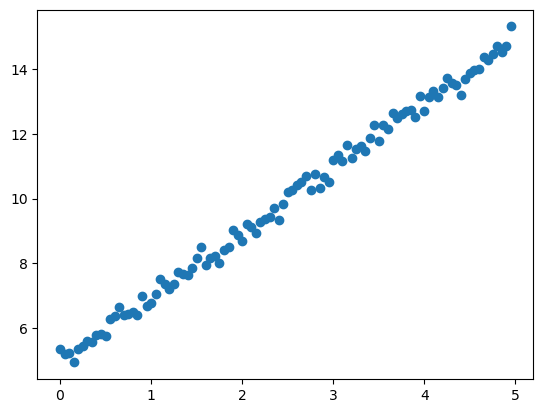

In [12]:
# 解析するデータのプロット
plt.plot(x,y,"o")
plt.show()

In [74]:
# メインのプログラム
num_para = 2 # パラメータ数
_sigma_R_ = 0.2/2 # ノイズ推定用の計算範囲を決めるため、予想されるノイズ標準偏差よりも小さい値を入れる。ノイズ推定をしない場合は真値を入れる。
_dir_ = "axbfit_2025_0117_18"# 解析結果の保存先フォルダ名を入力
os.mkdir(_dir_) # 保存先フォルダを作成。（フォルダが既に存在する場合はエラーとなる。）

# 初期値を事前分布から生成するか？
ini_pri = 1 # 1:生成する 0:生成しない（ハイパーパラメータ調整時以外は事前分布から生成する。）

np.random.seed(seed=1)# 解析結果に再現性を持たせるため乱数のseedを設定。

# stepsizeの調整
_st_p0_ = 9.5
_st_p1_ = 10.0

scale_d = 0.5
_d_p0_ = 1*scale_d
_d_p1_ = 1*scale_d

_alpha_p0_ = 10**(4)
_alpha_p1_ = 10**(3)

# 解析条件を設定
cycle = 5000#50000 #繰り返し回数
num_temp = 50 #逆温度の個数、偶数で設定
proportion = 1.4 #逆温度を生成する際の等比係数
burn_in_length = 2000#20000 #焼きなましの繰り返し回数

n = np.size(y)
ratio_p0 = np.zeros(num_temp)
ratio_p1 = np.zeros(num_temp)
ratio_temp = np.zeros(num_temp)
mean_E = np.zeros(num_temp)

# 初期値を設定（ハイパーパラメータ調整を行うときはプレフィットの値を入れる）
initial_p0 = 2
initial_p1 = 5

initial_p = np.ones(num_para)#パラメータ数の空箱を作る
initial_p[0] = initial_p0
initial_p[1] = initial_p1

# 各パラメータの範囲を事前分布として設定。
min_p0 = 0
max_p0 = 10
min_p1 = 0
max_p1 = 10

_p_max_ = np.array([max_p0,max_p1])
_p_min_ = np.array([min_p0,min_p1])
ratio_p = np.zeros((num_temp,np.size(_p_max_)))
rslt_p = [initial_p0,initial_p1]

# tempの生成 b=temp/sigma**2 : ノイズ推定を行う場合
_sigma_ = _sigma_R_#予測されるσよりも小さな値を入れる
sigma_R = 1 # ここを1とすることでtempにまとめる
temp = np.array([proportion**(j-num_temp+1)/_sigma_**2 for j in range(num_temp)])

# tempの生成 β=temp：ノイズ推定を行わない場合
#temp = np.array([proportion**(j-num_temp+1) for j in range(num_temp)])
#sigma_R = _sigma_R_ # sigma_Rにノイズ分散の真値を入れる

# stepsizeの生成 分岐点の情報をαとして入れる
stepsize_p0 = np.where(temp<=1/_alpha_p0_,_st_p0_,_st_p0_/(_alpha_p0_*temp)**_d_p0_)
stepsize_p1 = np.where(temp<=1/_alpha_p1_,_st_p1_,_st_p1_/(_alpha_p1_*temp)**_d_p1_)

temp[0] = 0
stepsize_p0[0] = _st_p0_
stepsize_p1[0] = _st_p1_

# プレフィット結果を初期値とする場合（ハイパーパラメータ調整を行う時のみ）
p0 = initial_p0*np.ones(num_temp)
p1 = initial_p1*np.ones(num_temp)
_p_ = np.ones(num_temp).reshape(num_temp,1)*initial_p

# 初期値を事前分布から乱数生成する場合
if(ini_pri==1):
    _p_ = np.zeros((num_temp,np.size(_p_max_)))
    _p_[:,0] = (_p_max_[0]-_p_min_[0])*np.random.rand(num_temp)+_p_min_[0]
    _p_[:,1] = (_p_max_[1]-_p_min_[1])*np.random.rand(num_temp)+_p_min_[1]

_y_ = axbfit(x,_p_)
E = 1/2/n/sigma_R**2*np.linalg.norm(y-(
         _y_
         ),axis=1)**2

E_ini = E[0]
_E_ = 1*E
_mean_E_ = 1*E
_rslt_p_ = 1*_p_
_rslt_p0_ = np.array(list(_p_[:,0]),dtype=object)#list(_p_[:,0])
_rslt_p1_ = np.array(list(_p_[:,1]),dtype=object)#list(_p_[:,1])
_ratio_p_ = np.array(list(np.ones(np.size(_p_max_)*num_temp)),dtype=object)#list(np.ones(np.size(_p_max_)*num_temp))
_optimal_ = list((_p_.reshape(np.size(_p_max_)*num_temp,1))[:,0])
_optimal_E_ = 1*E
_p_all_ = 1*(_p_.reshape(1,num_temp*np.size(_p_max_)))[0]

st = time.time()
for i in range(cycle):
    #配列は関数中で更新されるため取り出すのはEのみ
    E = update_param(i,E,n,num_para,sigma_R,x,y,_p_,ratio_p,rslt_p,_rslt_p0_,_rslt_p1_,stepsize_p0,stepsize_p1,
                 _ratio_p_,num_temp,_p_min_,_p_max_,burn_in_length)

    _p_all_ = np.append(_p_all_,1*(_p_.reshape(1,num_temp*np.size(_p_max_)))[0])

    if(i>=burn_in_length):
        mean_E += E
    _mean_E_ = np.append(_mean_E_,E)

    #Exchange_Process
    eo = np.mod(i,2)
    if(eo==0):
        prob = np.exp(n*(temp[eo+1::2]-temp[eo::2])*(E[eo+1::2]-E[eo::2])) - np.random.rand(int(num_temp/2))
        J = 2*np.array(np.where(prob>0))
    else:
        prob = np.exp(n*(temp[eo+1:num_temp-1:2]-temp[eo:num_temp-1:2])*(E[eo+1:num_temp-1:2]-E[eo:num_temp-1:2])) - np.random.rand(int(num_temp/2)-1)
        J = 2*np.array(np.where(prob>0))+1
    if(i>=burn_in_length):
        ratio_temp[J] += 1
    for j in J[0]:
        s = 1*_p_[j,:] # 参照を切るために1をかける
        _p_[j,:] = _p_[j+1,:]
        _p_[j+1,:] = s

    s = E[J]
    E[J] = E[J+1]
    E[J+1] = s
    # judge_optimal => ノイズ推定時どのレプリカが正解か確定しないので、Eの履歴を残して後から解析する
    _E_ = np.append(_E_,E)
    for j in range(np.size(_p_max_)*num_temp):
        if(i==0):
            _optimal_[j] = np.append(_optimal_[j],(_optimal_[j]))
        if(i>0):
            _optimal_[j] = np.append(_optimal_[j],(_optimal_[j])[-1])
    del_E = _optimal_E_ - E
    J = np.where(del_E>0)
    _optimal_E_[J] = 1*E[J]
    for j in J[0]:
        for k in range(np.size(_p_max_)):
            (_optimal_[j*np.size(_p_max_)+k])[-1] = _p_[j,k]


    if(np.mod(i+1,5000)==0):
        print(i+1,time.time()-st)
        np.save(_dir_+"/ratio_p.npy",ratio_p)
        np.save(_dir_+"/ratio_temp.npy",ratio_temp)
        np.save(_dir_+"/mean_E.npy",mean_E)
        np.save(_dir_+"/_rslt_p0_.npy",_rslt_p0_)
        np.save(_dir_+"/_rslt_p1_.npy",_rslt_p1_)
        np.save(_dir_+"/_E_.npy",_E_)
        np.save(_dir_+"/_p_all_.npy",_p_all_)
        np.save(_dir_+"/_mean_E_.npy",_mean_E_)
        np.save(_dir_+"/_ratio_p_.npy",_ratio_p_)
        np.save(_dir_+"/_optimal_.npy",_optimal_)

print(time.time()-st)

5000 19.85117793083191
19.899292469024658


In [75]:
_dir_

'axbfit_2025_0117_18'

おおむね0.2から0.8の間に収まっていれば成功。


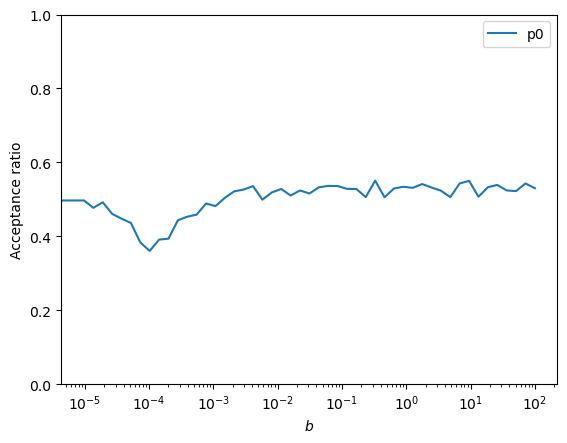

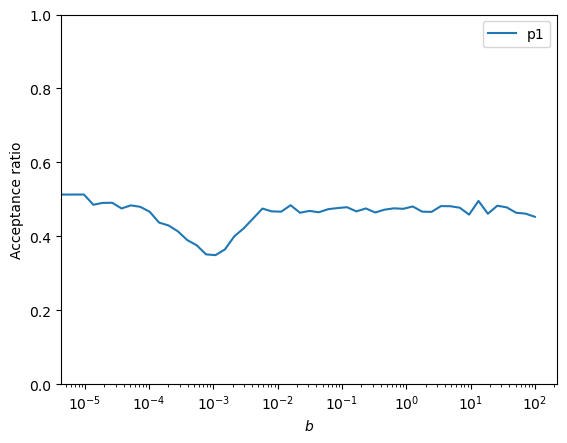

In [76]:
# 採択率のプロット
ratio_p = np.load(_dir_+"/ratio_p.npy")
print("おおむね0.2から0.8の間に収まっていれば成功。")
for i in range(num_para):
    plt.plot(temp,ratio_p[:,i]/(cycle-burn_in_length),label="p{}".format(i))
    plt.xscale("log")
    plt.ylim(0,1)
    plt.xlabel("$b$")
    plt.ylabel("Acceptance ratio")
    plt.legend()
    plt.show()

収束するまでの焼きなまし区間(burn_in)が十分か確認する。


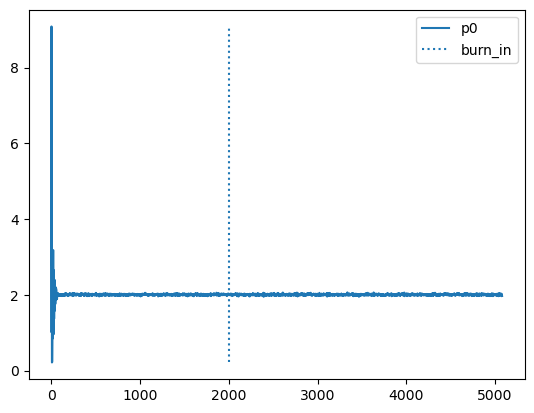

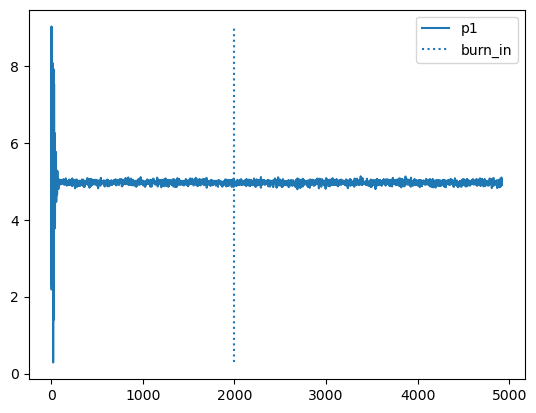

In [77]:
# 各パラメータの採択履歴をプロット
print("収束するまでの焼きなまし区間(burn_in)が十分か確認する。")
i = 44 # 履歴を確認したいレプリカのインデックス（逆温度の数が50の時は0から49までの番号）を入れる
for j in range(num_para):
    _pp_ = np.load(_dir_+"/_rslt_p{}_.npy".format(j), allow_pickle=True)
    plt.plot(_pp_[i],label="p{}".format(j))
    plt.vlines(burn_in_length,np.min(_pp_[i]),np.max(_pp_[i]),label="burn_in",linestyle="dotted")
    plt.legend()
    plt.show()

最高温度のレプリカ(b=0)との交換率(右の値がゼロで無いことを確認) 0.9653333333333334


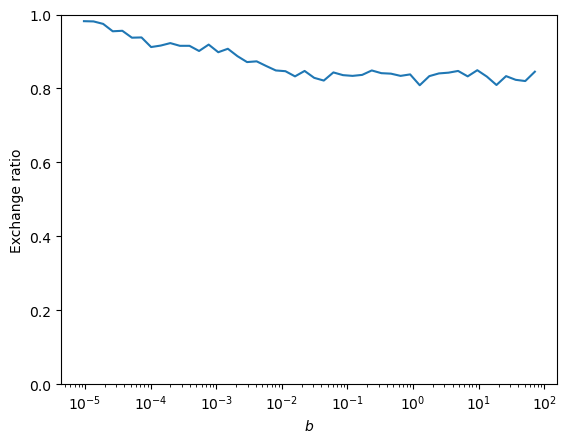

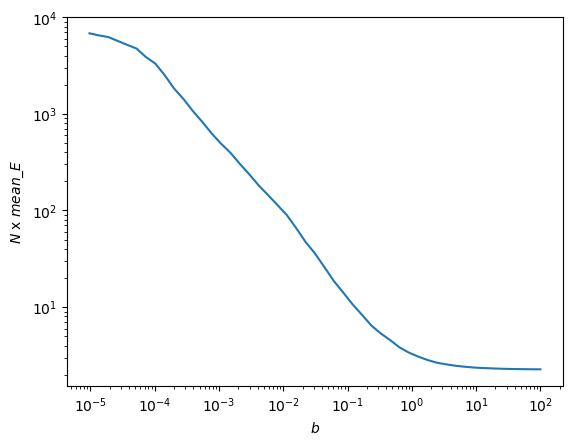

In [78]:
# レプリカ交換率とmean_Eのプロット
ratio_temp = np.load(_dir_+"/ratio_temp.npy")
mean_E = np.load(_dir_+"/mean_E.npy")
print("最高温度のレプリカ(b=0)との交換率(右の値がゼロで無いことを確認)",ratio_temp[0]/((cycle-burn_in_length)/2))
_ratio_temp_ = np.zeros((num_temp,2))
_ratio_temp_[:,0] = 1*temp
_ratio_temp_[:,1] = 1*ratio_temp/((cycle-burn_in_length)/2)
_mean_E_ = np.zeros((num_temp,2))
_mean_E_[:,0] = 1*temp
_mean_E_[:,1] = 1*mean_E/(cycle-burn_in_length)

plt.plot(temp[1:num_temp-1],ratio_temp[1:num_temp-1]/((cycle-burn_in_length)/2))
plt.xscale("log")
plt.xlabel("$b$")
plt.ylabel("Exchange ratio")
plt.ylim(0,1)
plt.show()
plt.plot(temp[1:num_temp],n*mean_E[1:num_temp]/(cycle-burn_in_length))
plt.xlabel("$b$")
plt.xscale("log")
plt.yscale("log")
plt.ylabel("$N$ x $mean$_$E$")
plt.show()

自由エネルギーの最小値 -2.962451180413886
推定されたノイズの標準偏差 0.23191032749750493
最適な逆温度のインデックス 44


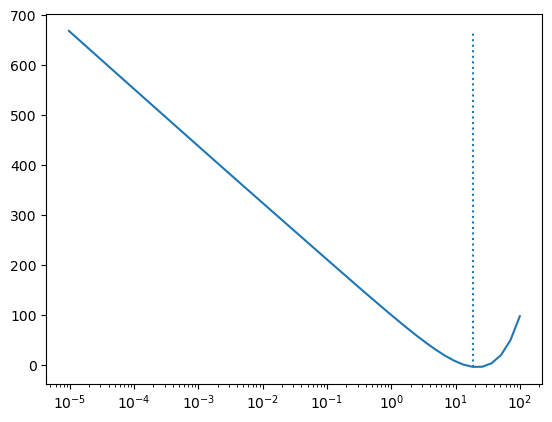

In [79]:
# ノイズ推定
F = []
for i in range(1,num_temp):
    A = 0
    for j in range(i):
        A += (temp[j+1] - temp[j])*mean_E[j+1]/(cycle-burn_in_length)*n
    F = np.append(F,A- n/2*(np.log(temp[i])-np.log(2*np.pi)))
plt.plot(temp[1:num_temp],F)
plt.xscale("log")
plt.vlines(temp[np.argmin(F)+1],np.min(F),np.max(F),linestyle="dotted")
#plt.yscale("log")
#plt.ylim(-200,500)
print("自由エネルギーの最小値",np.min(F))
print("推定されたノイズの標準偏差",1/(temp[np.argmin(F)+1])**0.5)
print("最適な逆温度のインデックス",np.argmin(F)+1)
plt.show()

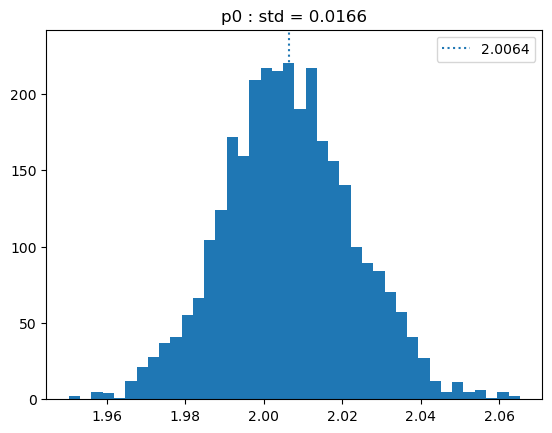

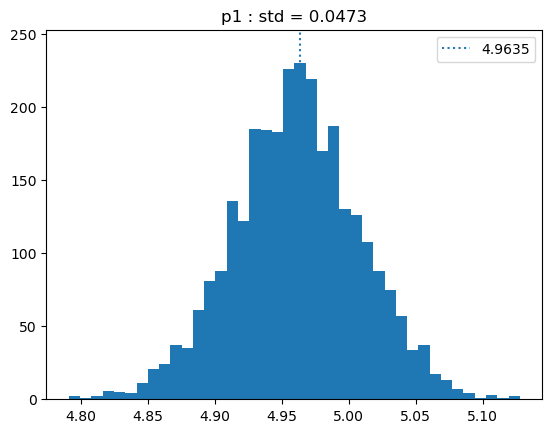

In [80]:
# 事後確率分布をプロット
i = np.argmin(F)+1 # ノイズ推定で得られた最適な逆温度のインデックスが入る
_pp_MPM_ = np.zeros(num_para)
for j in range(num_para):
    _pp_ = np.load(_dir_+"/_rslt_p{}_.npy".format(j), allow_pickle=True)
    plt.title("p{} : std = {:.4f}".format(j,np.std((_pp_[i])[burn_in_length::])))
    plt.hist((_pp_[i])[burn_in_length::],bins=40)
    _pp_hist_ = np.histogram((_pp_[i])[burn_in_length::],bins=40)
    _pp_MPM_[j] = ((_pp_hist_[1])[np.argmax(_pp_hist_[0])+1]+(_pp_hist_[1])[np.argmax(_pp_hist_[0])])/2
    plt.vlines(_pp_MPM_[j],0,1.1*np.max(_pp_hist_[0]),linestyle="dotted",label="{:.4f}".format(_pp_MPM_[j]))
    plt.ylim(0,1.1*np.max(_pp_hist_[0]))
    plt.legend()
    plt.show()

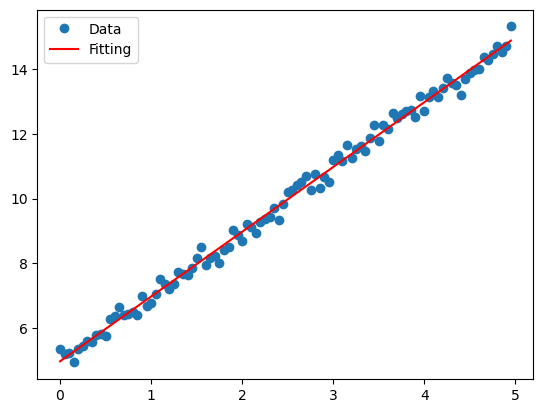

In [81]:
# パラメータごとの事後確率分布の最大値を用いたMPM(maximizer of the posterior marginal)推定によるフィッティング結果
a   = _pp_MPM_[0]
b   = _pp_MPM_[1]
_y_ = axb(x,a,b)

plt.plot(x,y,"o",label="Data")
plt.plot(x,_y_,color="r",label="Fitting")
plt.legend()
plt.show()

In [82]:
_pp_MPM_

array([2.00636325, 4.96347186])

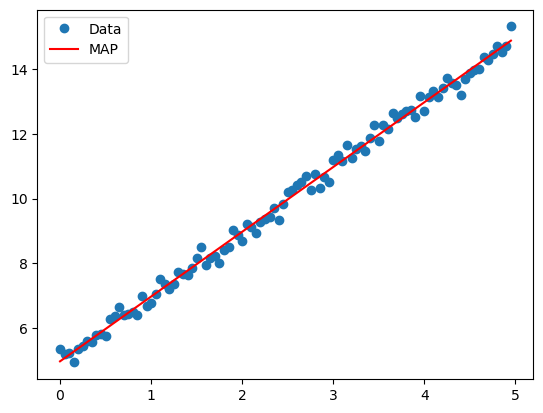

In [83]:
# MAP推定
_opt_j_ = np.argmin(F)+1
_pp_MAP_ = np.zeros(num_para)
_optimal_ = np.load(_dir_+"/_optimal_.npy")
for i in range(num_para):
    _pp_MAP_[i] = (_optimal_[num_para*_opt_j_+i])[cycle]
a   = _pp_MAP_[0]
b   = _pp_MAP_[1]
_y_ = axb(x,a,b)

plt.plot(x,y,"o",label="Data")
plt.plot(x,_y_,color="r",label="MAP")
plt.legend()
plt.show()

In [84]:
_pp_MAP_

array([2.0060581 , 4.96274874])